### analize simulation data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# for bessel functions and curve fitting
from scipy.optimize import curve_fit
from scipy import special

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],  # must be installed on your system
    "mathtext.fontset": "cm",             # Computer Modern math, matches LaTeX style
    "text.usetex": True,                    # render text via LaTeX
    "text.latex.preamble": r"\usepackage{amssymb}"
})

In [2]:
def plot_IV_curves(list_of_measurements, folder_path):
    plt.figure(figsize=(8, 5))

    for key in list_of_measurements.keys():
        plt.plot(list_of_measurements[key]['Voltage'], list_of_measurements[key]['Current'], 'o-', label=f"{key} $\\mu m$")

    plt.xlabel("Voltage / V")
    plt.ylabel("Current / mA")
    # plt.xlim(-0.5, 0.5)
    plt.title(os.path.basename(folder_path))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'IV_plot.pdf'), dpi=300)
    plt.savefig(os.path.join(folder_path, 'IV_plot.png'), dpi=300)
    plt.show()

In [3]:
def get_lin_fit(x, y):
    slope, intercept = np.polyfit(x, y, 1)
    y_fit = slope * x + intercept
    r_squared = 1- np.sum((y - y_fit)**2)/(np.sum((y - np.mean(y))**2)) # R^2 = 1 - SS_res / SS_tot = 1 - (y-y_fit)^2/(y-mean(y))^2

    return slope, intercept, r_squared

In [4]:
def get_R_from_lin_fit(list_of_measurements):
    R_list = []
    for key in list_of_measurements.keys():
        slope, intercept, r_squared = get_lin_fit(list_of_measurements[key]['Voltage'], list_of_measurements[key]['Current'])
        R_list.append((1/slope))  # in ohm
    return R_list

In [5]:
def sci_notation_latex(x, precision=2):
    mantissa, exp = f"{x:.{precision}e}".split("e")
    return rf"{mantissa} \cdot 10^{{{int(exp)}}}"

In [17]:
# @param geometries: arrays with the ditances and inner radius of the CTLM structure
# @param Rsh: sheet resistance -> initial guess
# @param Lt: transfer length -> initial guess
# this still uses the assumption of R_sh being constant under and between the contacts
def ctlm_bessel_model(geometries, Rsh, L_T):
        
        (distances, r_inner) = geometries
        # Term 1: Resistance of the semiconductor gap
        term_gap = np.log((r_inner + distances) / r_inner)
        
        # Term 2: Resistance of the inner contact (using using bessel functions I0 and I1)
        term_inner = (L_T / r_inner) * (special.i0(r_inner / L_T) / special.i1(r_inner / L_T))
        
        # Term 3: Resistance of the outer contact (using bessel functions K0 and K1)
        term_outer = (L_T / (r_inner + distances)) * (special.k0((r_inner + distances) / L_T) / special.k1((r_inner + distances) / L_T))
        
        # Total Resistance
        R_T = (Rsh / (2 * np.pi)) * (term_gap + term_inner + term_outer)

        return R_T

def plot_ctlm_fit(distances, R_list, r_inner, folder_path):
    # Initial Guess: [Rsh, Lt]
    # p0 = [R_sh_linear, L_T_linear]
    p0 = [1, 100]
    # p0 = [1, 1]
    bounds = ([0, 0], [np.inf, np.inf])
    r_inner_array = np.full_like(distances, r_inner)

    popt, pcov = curve_fit(ctlm_bessel_model, (distances, r_inner_array), R_list, p0=p0, bounds=bounds)

    Rsh_fit, Lt_fit = popt

    rho_c_fit = Rsh_fit * (Lt_fit**2) * 1e-8  # 1e-8 to convert from ohm·μm² to ohm·cm²

    distances_smooth = np.linspace(0, max(distances), 300) # min(distances)
    ri_smooth = np.full_like(distances_smooth, r_inner)
    Rt_fit_curve = ctlm_bessel_model((distances_smooth, ri_smooth), Rsh_fit, Lt_fit)

    plt.figure()
    plt.scatter(distances, R_list, color='orange', marker='o', label='Measured Resistance')
    plt.plot(distances_smooth, Rt_fit_curve, color='blue', linestyle='--', label='Bessel Function Fit')

    tlm_text = (
        f"$R_{{sh}} = {Rsh_fit:.2f} \\, \\Omega / \\square$\n"
        f"$L_T = {Lt_fit:.2f} \\, \\mu m$\n"
        f"$\\rho_C = {sci_notation_latex(rho_c_fit)} \\, \\Omega cm^2$"
    )

    plt.gca().text(
        0.95, 0.1, tlm_text,
        fontsize=9,
        transform=plt.gca().transAxes,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='gray')
    )

    plt.axhline(0, color='black', linewidth=1.5)
    plt.axvline(0, color='black', linewidth=1.5)

    plt.title(os.path.basename(folder_path))
    plt.xlabel("Contact Spacing / $\\mu m$")
    plt.ylabel("Total Resistance / $\\Omega$")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    # plt.xlim(0, max(list_of_measurements.keys())+20)
    plt.savefig(os.path.join(folder_path, 'cTLM_plot.pdf'), dpi=300)
    plt.savefig(os.path.join(folder_path, 'cTLM_plot.png'), dpi=300)
    plt.show()

    return [Rsh_fit, Lt_fit, rho_c_fit]

In [6]:
def get_Rsh(N_D):
    # R□​=ρ/t​=1/q⋅N⋅μ⋅t​
    t = 0.035
    q = 1.602176634e-19
    mobility = 900
    return 1 / (q*N_D*mobility*t)

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=1e17_rho=1e-4
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


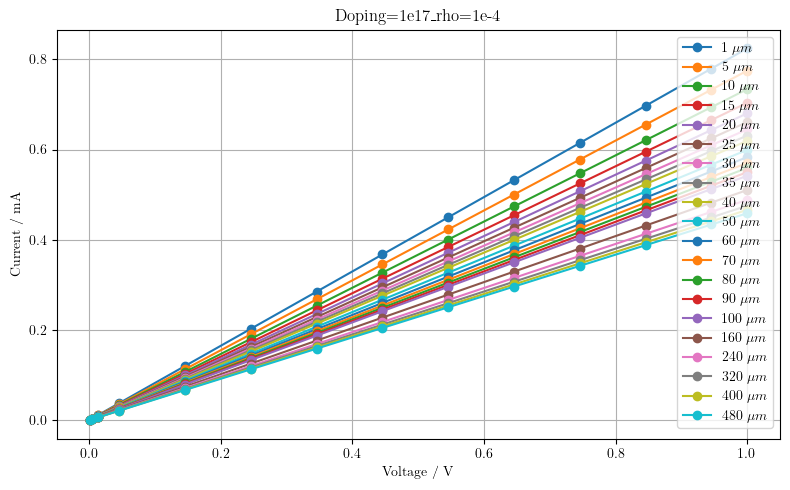

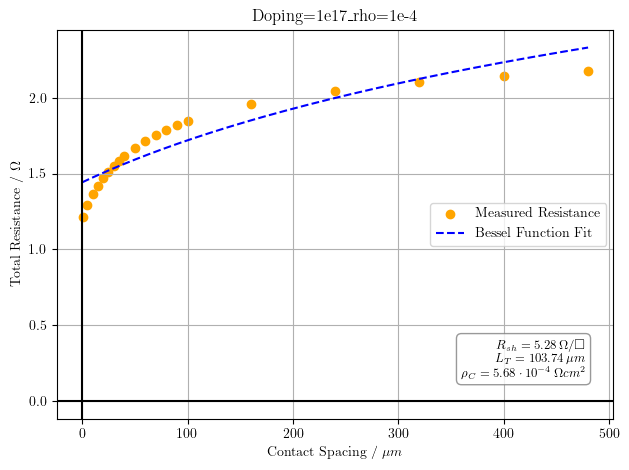

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=1e17_rho=1e-5
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


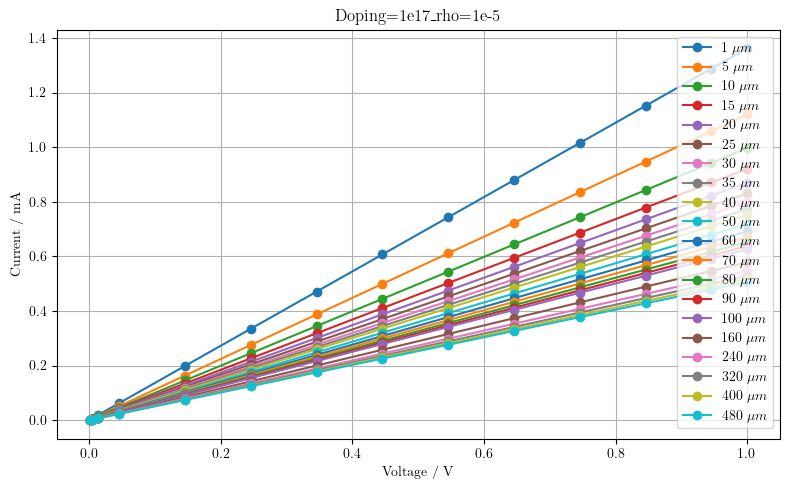

C:\Users\lhager\AppData\Local\Temp\ipykernel_9460\637789891.py:12: RuntimeWarning: invalid value encountered in divide
  term_inner = (L_T / r_inner) * (special.i0(r_inner / L_T) / special.i1(r_inner / L_T))
C:\Users\lhager\AppData\Local\Temp\ipykernel_9460\637789891.py:15: RuntimeWarning: invalid value encountered in divide
  term_outer = (L_T / (r_inner + distances)) * (special.k0((r_inner + distances) / L_T) / special.k1((r_inner + distances) / L_T))


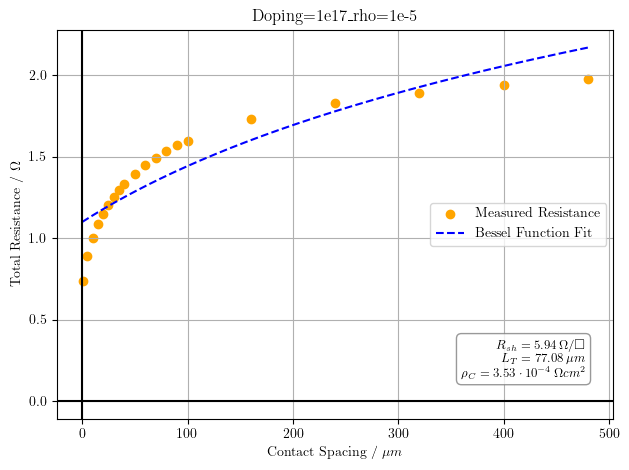

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=1e17_rho=5e-5
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


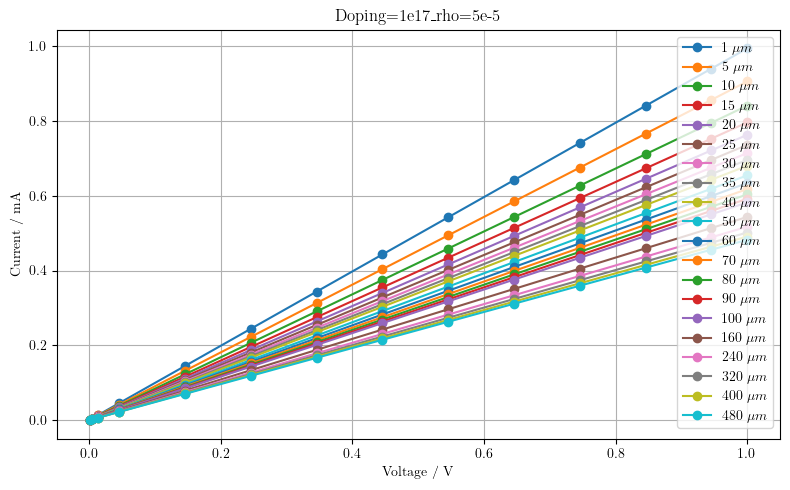

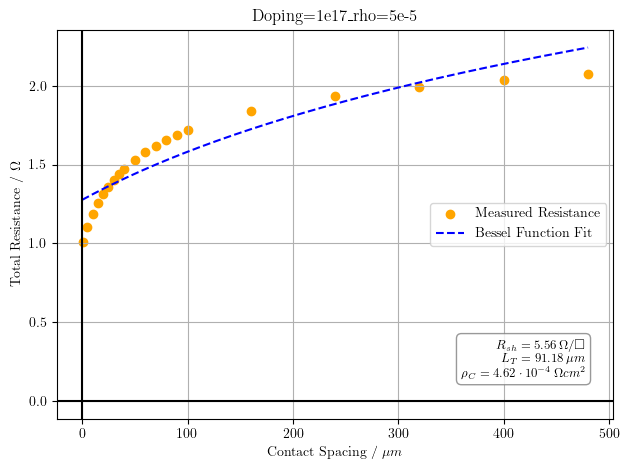

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=1e18_rho=1e-4
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


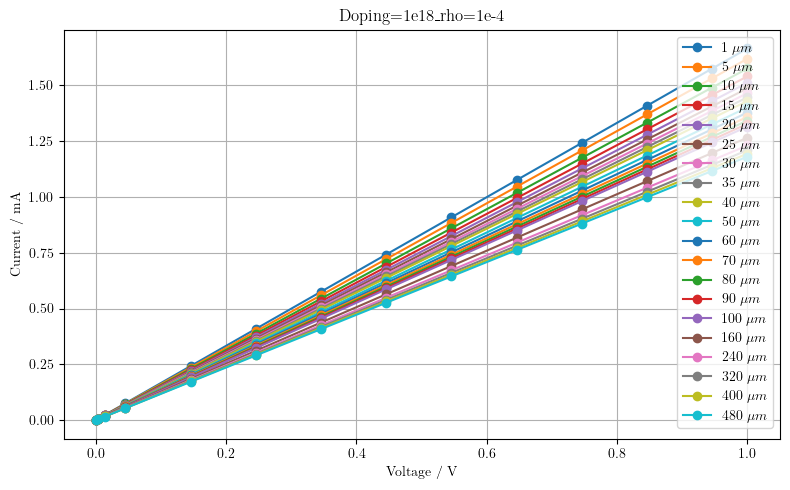

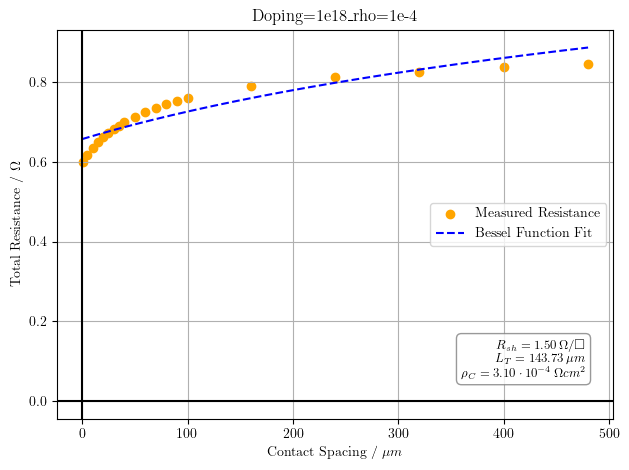

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=1e18_rho=1e-5
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


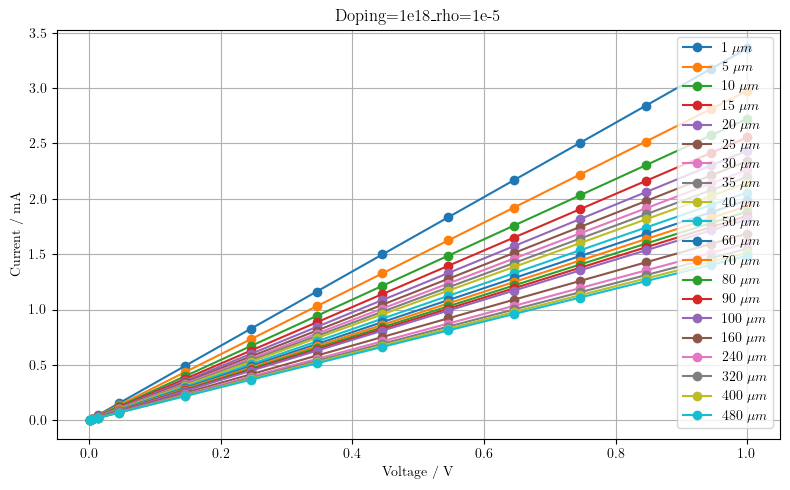

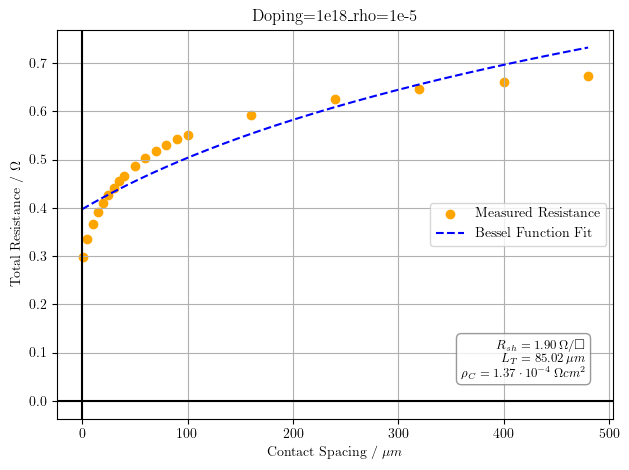

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=1e18_rho=5e-5
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


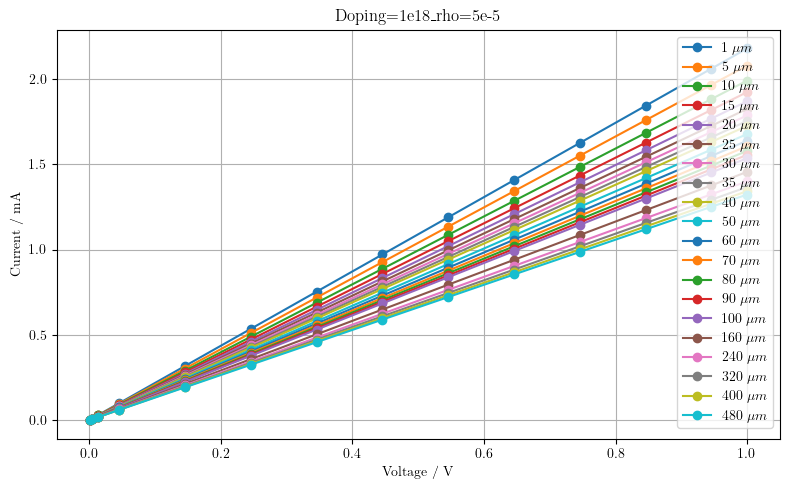

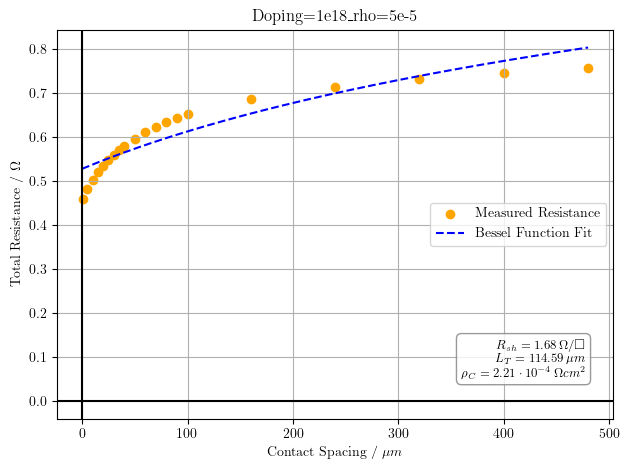

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=1e19_rho=1e-4
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


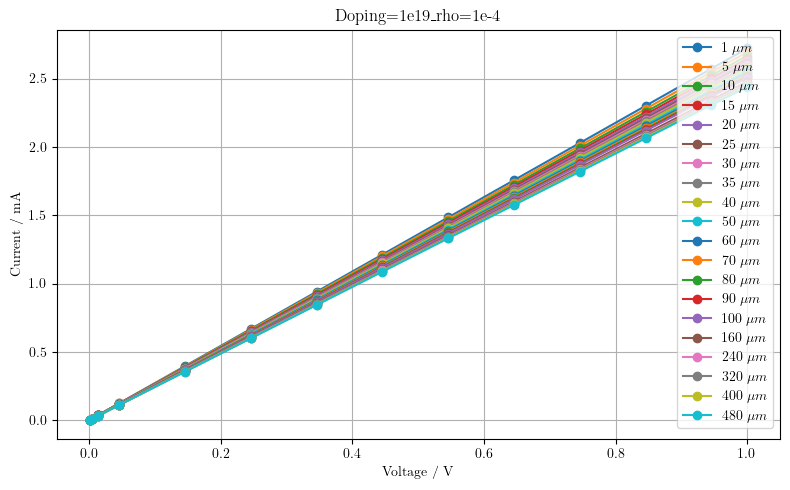

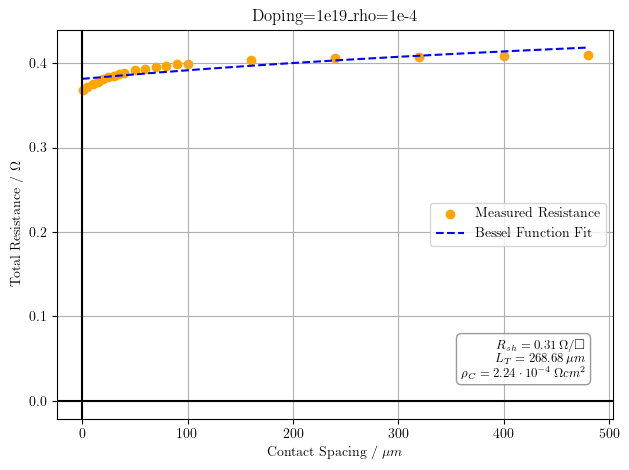

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=1e19_rho=1e-5
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


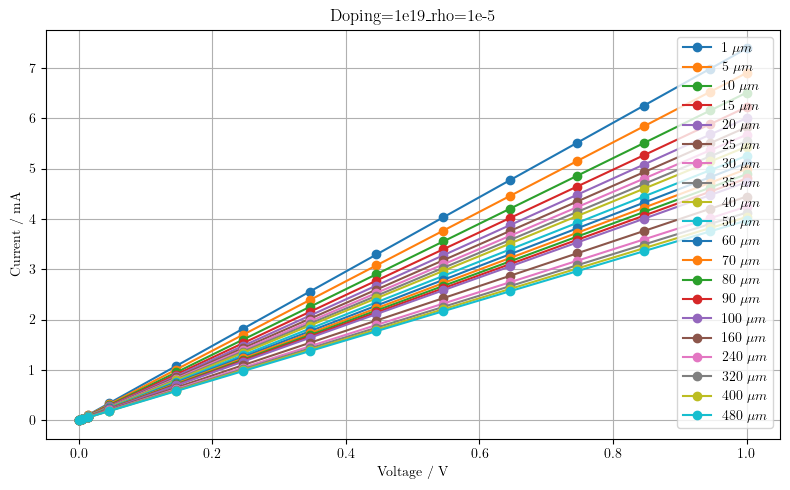

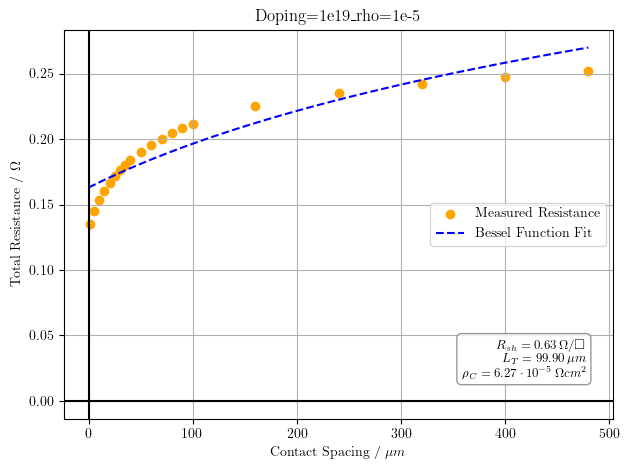

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=1e19_rho=5e-5
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


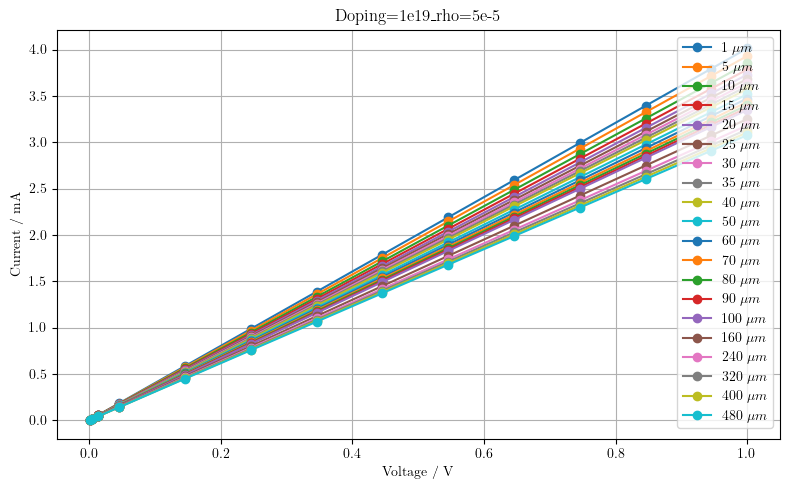

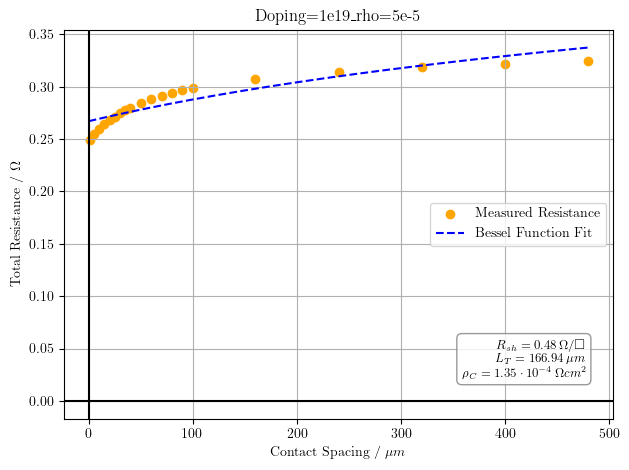

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=4e18_rho=1e-4
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


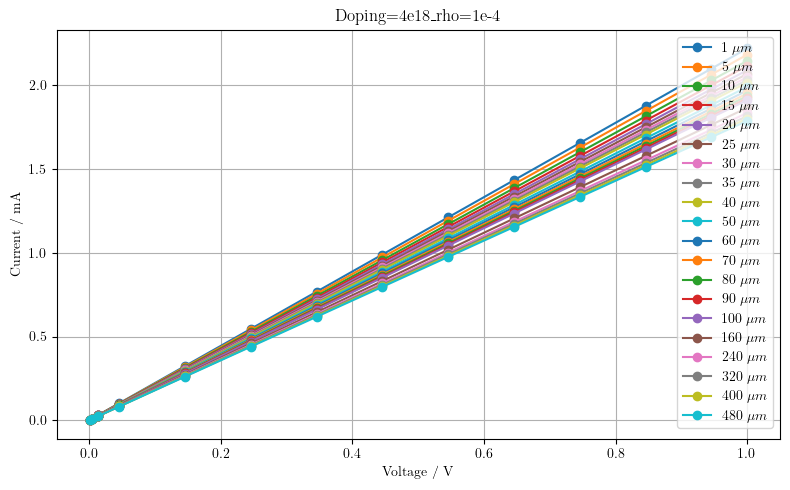

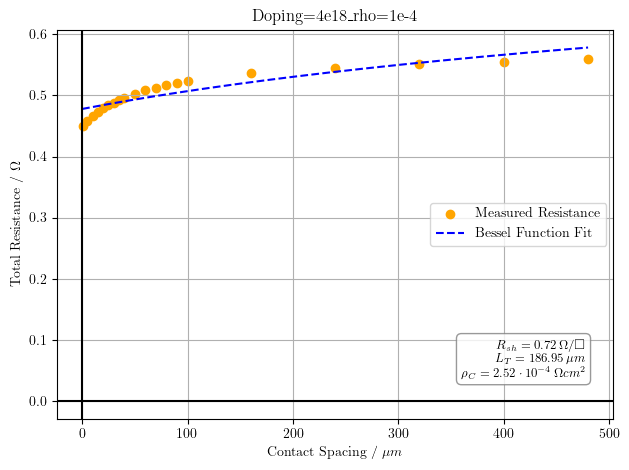

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=4e18_rho=1e-5
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


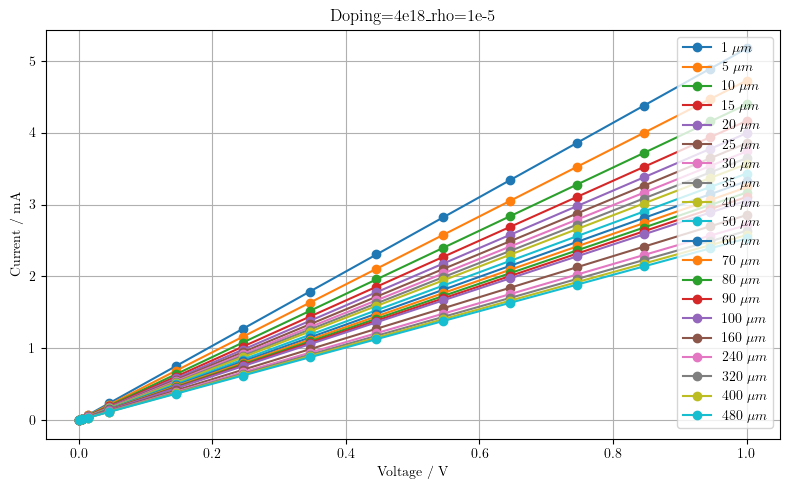

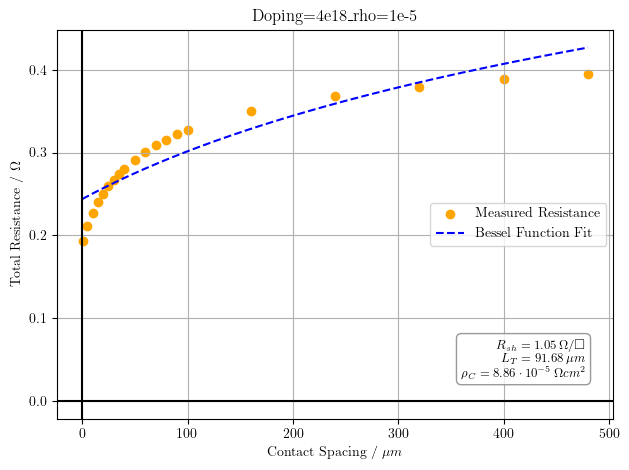

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=4e18_rho=5e-5
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


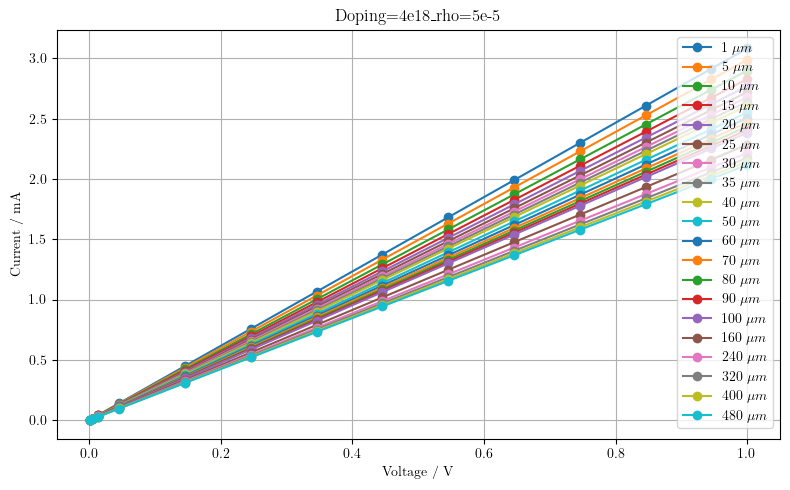

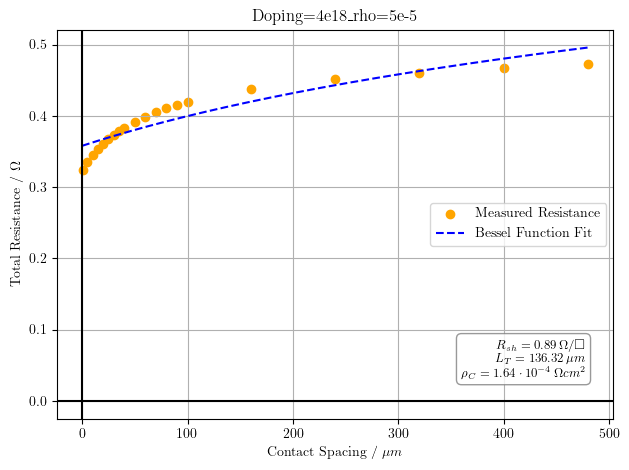

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=5e17_rho=1e-4
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


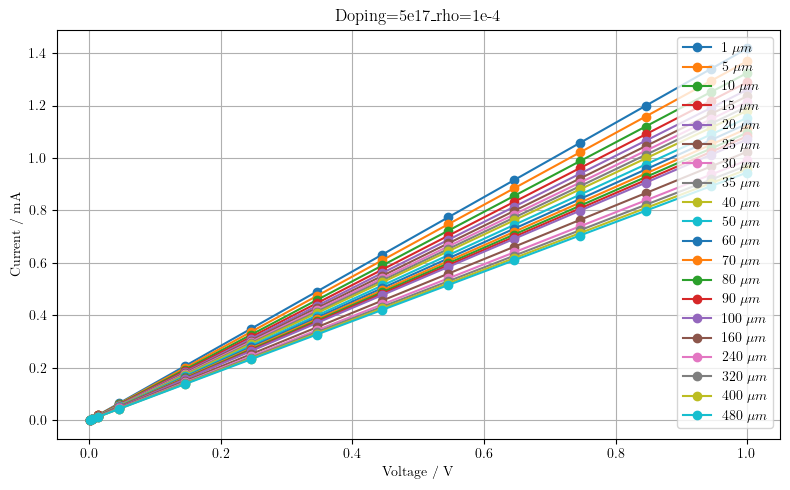

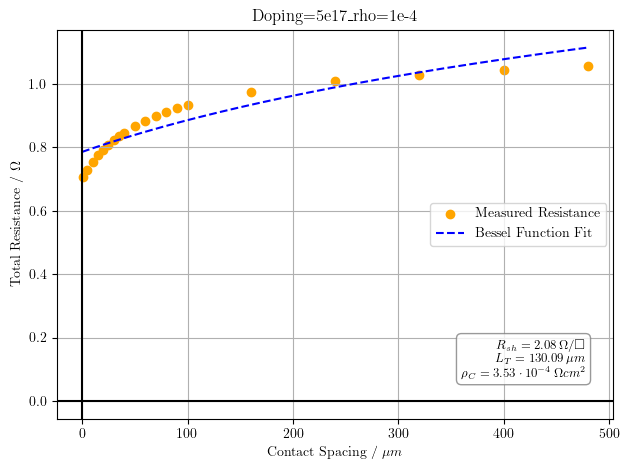

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=5e17_rho=1e-5
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


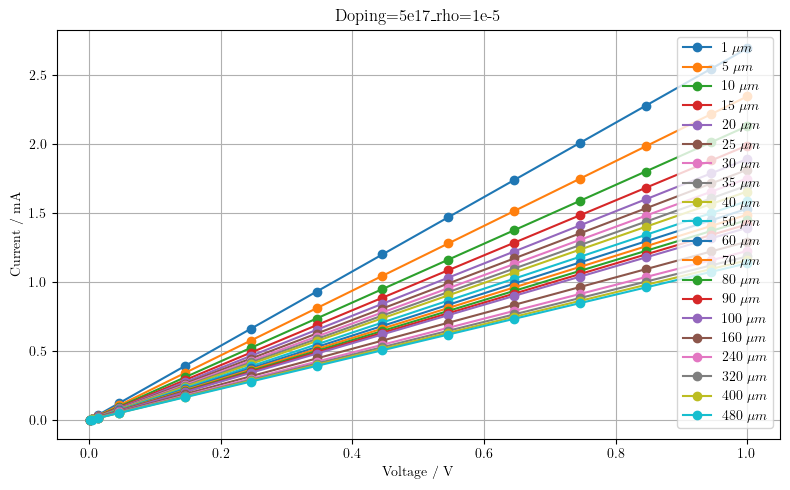

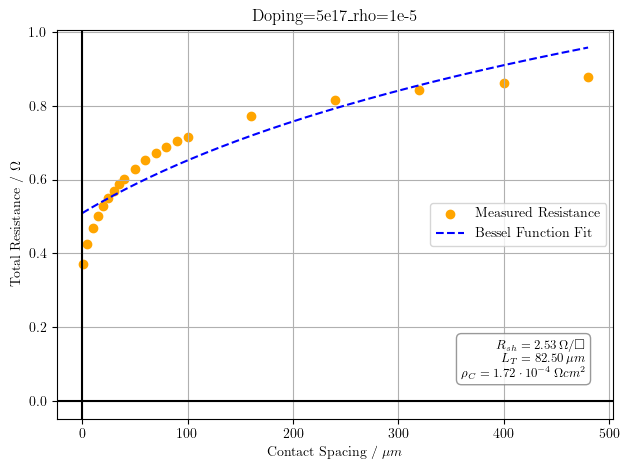

Processing folder: K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350\Doping=5e17_rho=5e-5
[1, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 100, 160, 240, 320, 400, 480]


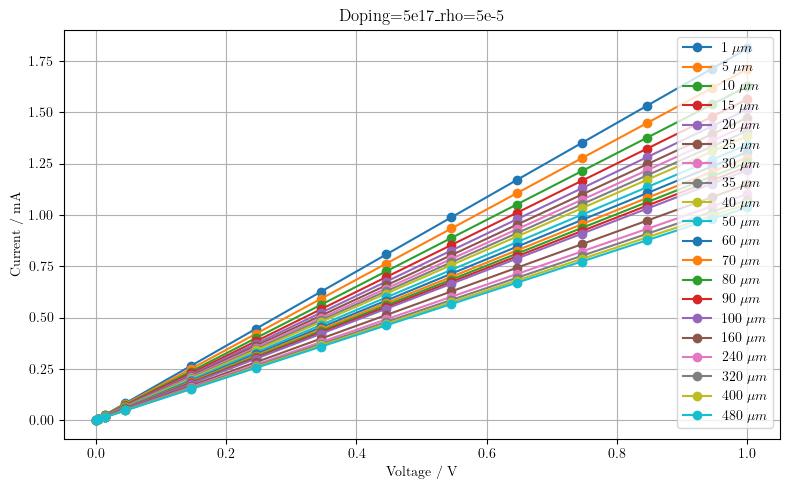

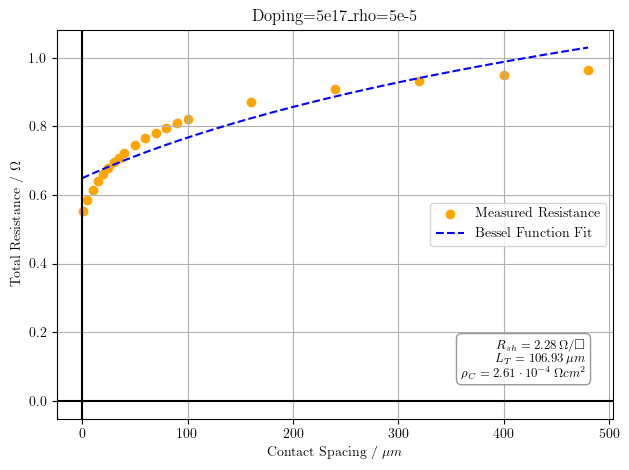

In [18]:
from readTLMData import TLMREADER
parent_folder = r"K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVDataCTLM_contactlength=150_subthickness=350"

results = []
for folder in os.listdir(parent_folder):
    folder_path = os.path.join(parent_folder, folder)
    if os.path.isdir(folder_path):
        print(f"Processing folder: {folder_path}")

        list_of_measurements = TLMREADER(folder_path).get_simulation_data()
        list_of_measurements = dict(sorted(list_of_measurements.items()))

        # keys_to_remove = [1, 5, 10, 15, 20, 25, 30, 35]
        # for k in keys_to_remove:
        #     list_of_measurements.pop(k, None)

        r_inner = 150
        distances = list(map(int, list_of_measurements.keys()))
        print(distances)

        R_list = get_R_from_lin_fit(list_of_measurements)
        plot_IV_curves(list_of_measurements, folder_path)

        # doping = float(re.search(r'Doping=(\d+e[-+]?\d+)', folder).group(1))
        # R_sh_sim = get_Rsh(doping)
        # rho_c = float(re.search(r'rho=(\d+e[-+]?\d+)', folder).group(1))
        # L_T_sim = np.sqrt(rho_c/R_sh_sim) * 10000

        fit_params = plot_ctlm_fit(distances, R_list, r_inner, folder_path)
        results.append({
            'Name': folder,
            'rho_c_set': float(re.search(r'rho=(\d+e[-+]?\d+)', folder).group(1)) if re.search(r'rho=(\d+e[-+]?\d+)', folder) else None,
            'Doping': float(re.search(r'Doping=(\d+e[-+]?\d+)', folder).group(1)) if re.search(r'Doping=(\d+e[-+]?\d+)', folder) else None,
            'R_sh': fit_params[0],
            'L_T': fit_params[1],
            'rho_c': fit_params[2]
        })

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(parent_folder, 'ctlm_fit_results.csv'), index=False)

### plot results

In [43]:
# results_path = r"K:\tech_stud\Hager_Lutz\Master\Data\Simulation\IVData_contactlength=150_subthickness=150_VarImplant_Varrho\ctlm_fit_results.csv"
# results_df = pd.read_csv(results_path)
# print(results)

# Ni_cTLM_1030°C, 4.33E+18, 0.98, 112.58, 1.24E-04

In [61]:
results_df.sort_values(by=['Doping', 'rho_c_set'], ascending=[True, False], inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df.head()

,Name,rho_c_set,Doping,R_sh,L_T,rho_c
0,Doping=1e17_rho=1e-4,0.00010,1.000000e+17,4.005720,135.880838,0.000740
1,Doping=1e17_rho=5e-5,0.00005,1.000000e+17,4.176918,123.889169,0.000641
2,Doping=1e17_rho=1e-5,0.00001,1.000000e+17,4.353429,112.154076,0.000548
3,Doping=5e17_rho=1e-4,0.00010,5.000000e+17,1.585352,163.503257,0.000424
4,Doping=5e17_rho=5e-5,0.00005,5.000000e+17,1.731796,139.009597,0.000335


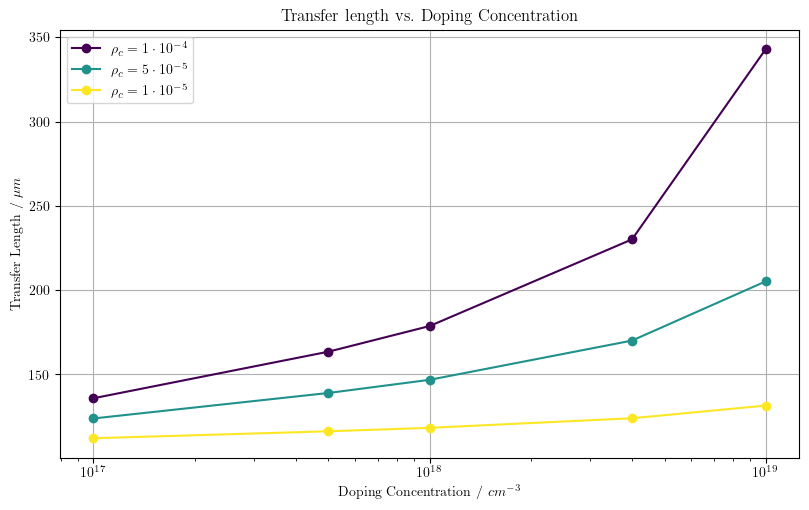

In [62]:
fig = plt.figure(figsize=(8, 5))

# cmap = plt.get_cmap('viridis')
# colors = cmap(np.linspace(0, 0.80, 3)) 
colors = plt.get_cmap('viridis', 3)

plt.semilogx(results_df.loc[results_df['rho_c_set']==1e-4, 'Doping'], results_df.loc[results_df['rho_c_set']==1e-4, 'L_T'], label=f'$\\rho_c={sci_notation_latex(1e-4, precision=0)}$', color=colors(0), marker='o')
plt.semilogx(results_df.loc[results_df['rho_c_set']==5e-5, 'Doping'], results_df.loc[results_df['rho_c_set']==5e-5, 'L_T'], label=f'$\\rho_c={sci_notation_latex(5e-5, precision=0)}$', color=colors(1), marker='o')
plt.semilogx(results_df.loc[results_df['rho_c_set']==1e-5, 'Doping'], results_df.loc[results_df['rho_c_set']==1e-5, 'L_T'], label=f'$\\rho_c={sci_notation_latex(1e-5, precision=0)}$', color=colors(2), marker='o')

plt.legend()
plt.title('Transfer length vs. Doping Concentration')
plt.tight_layout()
plt.xlabel('Doping Concentration / $cm^{-3}$')
plt.ylabel('Transfer Length / $\\mu m$')
plt.grid(True)
# plt.savefig(os.path.join(parent_folder, 'combined_L_T.pdf'), dpi=300)
plt.show()

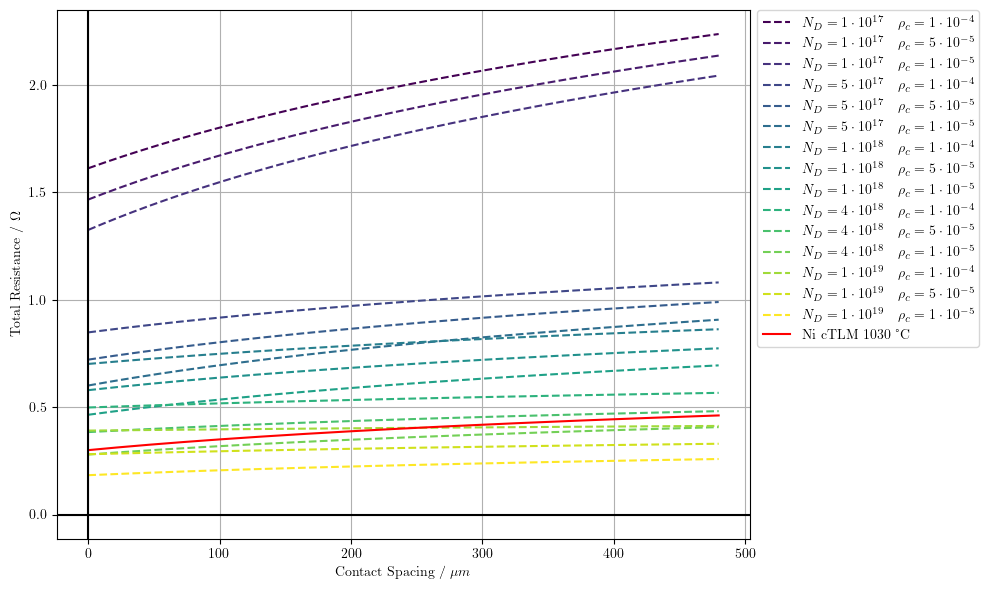

In [63]:
distances_smooth = np.linspace(0, max(distances), 300) # min(distances)
ri_smooth = np.full_like(distances_smooth, r_inner)

# results_df = results_df.iloc[6:]
# results_df.reset_index(drop=True, inplace=True)

plt.figure(figsize=(10, 6))

colors = plt.get_cmap('viridis', len(results_df))
for index, row in results_df.iterrows():
    Rt_fit_curve = ctlm_bessel_model((distances_smooth, ri_smooth), row['R_sh'], row['L_T'])
    plt.plot(distances_smooth, Rt_fit_curve, color=colors(index), linestyle='--', label=f'$N_D={sci_notation_latex(row["Doping"], precision=0)}\\quad \\rho_c={sci_notation_latex(row['rho_c_set'], precision=0)}$')

# Ni_cTLM_1030°C, 4.33E+18, 0.98, 112.58, 1.24E-04
Rt_fit_curve = ctlm_bessel_model((distances_smooth, ri_smooth), 0.98, 112.58)
plt.plot(distances_smooth, Rt_fit_curve, color='red', linestyle='-', label='Ni cTLM 1030 °C')

plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)

# plt.title(os.path.basename(folder_path))
plt.xlabel("Contact Spacing / $\\mu m$")
plt.ylabel("Total Resistance / $\\Omega$")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
# plt.xlim(0, max(list_of_measurements.keys())+20)
plt.grid(True)
# plt.savefig(os.path.join(parent_folder, 'combined_cTLM_results_2.pdf'), dpi=300)
plt.show()

### ploting current density

In [40]:
folder_path = r"K:\tech_stud\Hager_Lutz\Master\Data\Simulation\currentDensities_350um_1e-4"

dict_of_simulations = {}
for file in os.listdir(folder_path):
    if file.endswith('.csv'):

        currentDens = pd.read_csv(os.path.join(folder_path, file), header=1)
        currentDens.columns = ['depth', 'CurrentDensity']
        dict_of_simulations[os.path.splitext(os.path.basename(file))[0]] = currentDens

dict_of_simulations = dict(sorted(dict_of_simulations.items(), key=lambda x: float(x[0]), reverse=True))
print(dict_of_simulations.keys())

dict_keys(['1e19', '4e18', '1e18', '5e17'])


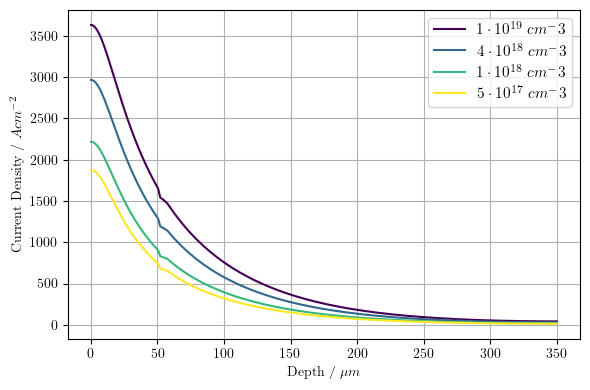

In [ ]:
fig = plt.figure(figsize=(6, 4))

colors = plt.get_cmap('viridis', len(dict_of_simulations))
# plt.semilogy(currentDens['depth'], currentDens['CurrentDensity'])
for index, doping in enumerate(dict_of_simulations):
    plt.plot(dict_of_simulations[doping]['depth'], dict_of_simulations[doping]['CurrentDensity'], label=f'${sci_notation_latex(float(doping), precision=0)}$ $cm^{-3}$', color=colors(index))

plt.xlabel('Depth / $\\mu m$')
plt.ylabel('Current Density / $Acm^{-2}$')
plt.grid(True)
plt.legend(fontsize=11)
plt.tight_layout()
# plt.savefig(os.path.join('../Images/Simulation', 'currentDensity.pdf'), dpi=300)
plt.show()